In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

In [2]:
import numpy as np
import pandas as pd

In [3]:
stw1, stw2 = 7077176154, 7077178969

In [4]:
from pathlib import Path

from odin.level0.acfile import ACfile
from odin.level0.attfile import AttFile
from odin.level0.fbafile import FBAfile
from odin.level0.shkfile import SHKfile
from odin.level1.process import Level1

file = Path("./data/1a5d2ae7.ac1")
ac = ACfile(file).dataframe
att = AttFile(Path("./data/1a5c499d.att")).dataframe
shk = SHKfile(Path("./data/1a5d2ae9.shk")).dataframe
fba = FBAfile(Path("./data/1a5d2ae8.fba")).dataframe

Applying overflow correction
datetime    datetime64[ms, UTC]
stw                      uint64
orbit                   float64
qt                       object
qa                       object
qe                       object
gps                      object
os_pos                   object
smr_pos                  object
sci                      uint16
mode                     uint16
acs                     float64
dtype: object


In [5]:
l1 = Level1(
    ac=ac,
    att=att,
    shk=shk,
    fba=fba,
)

uint64 uint64
int64
30.360964 29.986813 30.670574
(4608,) (4396,) (204,) (9215,)
kfactor stats: 1.0000182801444755
lo_corr shape (4608,)
deltaf [[[          nan]]

 [[1.0000033e+06]]

 [[1.0000033e+06]]

 ...

 [[1.0000031e+06]]

 [[1.0000031e+06]]

 [[1.0000031e+06]]]
stw
7077015155     68.189412
7077015219     65.349942
7077015283     62.510529
7077015347     59.660294
7077015411     56.800057
                 ...    
7077309643    116.056646
7077309707    118.796121
7077309771    121.525821
7077309835    124.231062
7077309899    126.931999
Name: t_height, Length: 4608, dtype: float64


/workspace/odin/src/odin/level1/intensity_calibration.py:54: RuntimeWarning: invalid value encountered in divide
  pe_hi = np.where(mask, (S_hi - C_hi) / span_hi, np.nan)
/workspace/odin/src/odin/level1/intensity_calibration.py:55: RuntimeWarning: All-NaN slice encountered
  PE = np.nanmedian(pe_hi, axis=0)
/workspace/odin/src/odin/level1/intensity_calibration.py:56: RuntimeWarning: All-NaN slice encountered
  PE = PE - np.nanmedian(PE, axis=-1, keepdims=True)
/workspace/odin/src/odin/level1/intensity_calibration.py:97: RuntimeWarning: invalid value encountered in log1p
  return np.where(Jb > 0, T0 / np.log1p(T0 / Jb), 0.0)
/workspace/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


## Sweeps identification

In [6]:
# sync = l1.shk["ACDC1 sync"].astype("uint16").to_numpy() >> 3 & 0xF
# print(sync[40:60])
# mask = np.where((sync == 5) |  (sync == 10) )
# stws = l1.ac.index[mask]
# stws

In [7]:
def stitch_full_band(x: np.ndarray, y: np.ndarray):
    """
    x, y: (n, 8, 112)
    returns: x_full, y_full: (n, 896) where x_full is monotonic increasing per row
    """
    assert x.shape == y.shape
    n = x.shape[0]

    X = x.reshape(n, -1)  # (n, 896)
    Y = y.reshape(n, -1)  # (n, 896)

    # If x can contain NaNs, push them to the end (optional)
    X_for_sort = np.where(np.isnan(X), np.inf, X)

    idx = np.argsort(X_for_sort, axis=1, kind="mergesort")  # stable sort
    rows = np.arange(n)[:, None]

    X_full = X[rows, idx]
    Y_full = Y[rows, idx]
    return X_full, Y_full

In [8]:
np.stack(l1.calibrated["calibrated"].loc[stw1:stw2].to_numpy())[:2,:,:4]

array([[[         nan,          nan,          nan,          nan],
        [218.24030069, 216.60224802, 215.83820201, 212.63933692],
        [233.51282471, 232.17863162, 231.95321263, 234.71808943],
        [229.18153646, 229.09521274, 231.44796771, 231.80225647],
        [235.34694199, 233.22797   , 232.10355781, 234.28711552],
        [236.17954951, 236.72126373, 234.79749788, 234.20420805],
        [251.07887922, 254.01117645, 253.83508926, 249.995627  ],
        [256.26054778, 253.86967877, 251.34655753, 250.58219074]],

       [[         nan,          nan,          nan,          nan],
        [208.30102116, 209.48938758, 212.0419553 , 210.84352895],
        [236.40449784, 235.37897378, 235.01477592, 237.08847662],
        [230.67658489, 231.07473747, 235.26783865, 236.52037492],
        [232.1532795 , 231.92753873, 233.83385229, 236.9502172 ],
        [231.91925759, 231.66853546, 231.46992797, 235.0090174 ],
        [249.77208876, 247.69604463, 248.3038032 , 248.90937638],
        

In [9]:
freq = np.stack(
    l1.frequency_grid["frequency_grid"].loc[stw1:stw2].to_numpy()
).astype(np.float64)
freq[:1,:,[1,-1]]

array([[[5.57300505e+11, 5.57410505e+11],
        [5.57298505e+11, 5.57188505e+11],
        [5.56700508e+11, 5.56810509e+11],
        [5.56698508e+11, 5.56588508e+11],
        [5.57098506e+11, 5.56988506e+11],
        [5.57100506e+11, 5.57210506e+11],
        [5.56898507e+11, 5.56788507e+11],
        [5.56900507e+11, 5.57010508e+11]]])

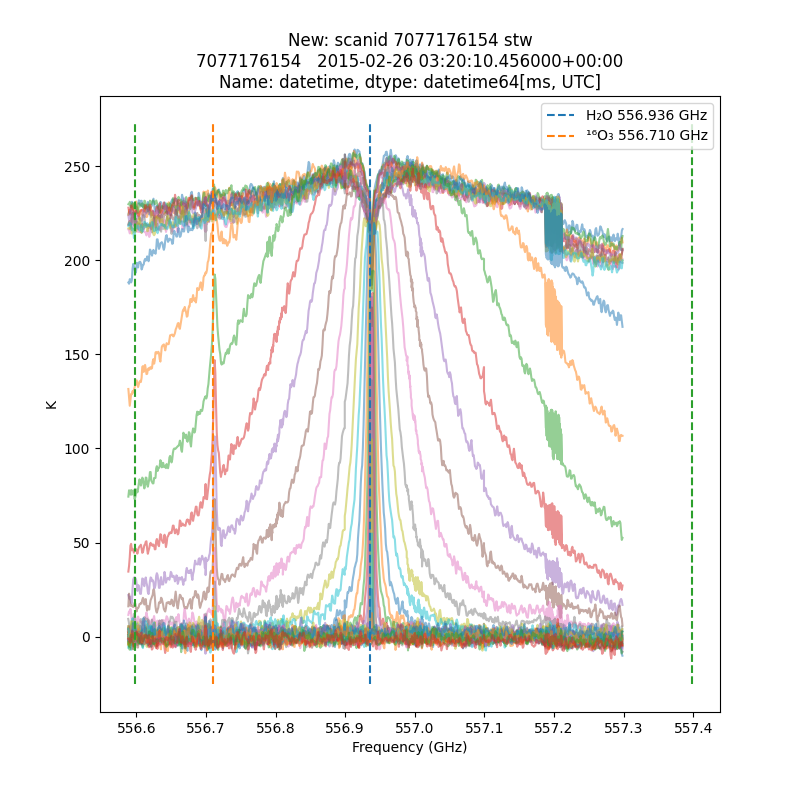

In [10]:
import matplotlib.pyplot as plt
plt.close("all")

freq = np.stack(
    l1.frequency_grid["frequency_grid"].loc[stw1:stw2].to_numpy()
).astype(np.float64)


cal = np.stack(l1.calibrated["calibrated"].loc[stw1:stw2].to_numpy())

fig, ax = plt.subplots(figsize=(8, 8))
x, y = stitch_full_band(freq, cal)
# markers = ["o", "s", "^", "v", "D", "x", "+", "*"]  # 8 different markers

# for i in range(8):
#     ax.plot(
#         freq[:, i, :].squeeze()[:,:102].T / 1e9,
#         cal[:, i, :].squeeze()[:,:102].T,
#         ls="none",
#         marker=markers[i],
#         alpha=0.5,
#         label=f"Band {i}",
#     )
ax.plot(
    x.T / 1e9,
    y.T,
    # ls="none",
    # marker=".",
    alpha=0.5,
    # color="C0",
    # label="new",
)
ymin,ymax=ax.get_ylim()[0],ax.get_ylim()[1],
if l1.ac.backend.iloc[0] == "AC1":
    ax.vlines(
            x=[556.936, 556.598, 557.398],
            ymin=ymin,
            ymax=ymax,
            colors=["C0","C2","C2"],
            linestyles="--",
            label="H₂O 556.936 GHz",
        )
    ax.vlines(
            x= 556.710,
            ymin=ymin,
            ymax=ymax,
            colors="C1",
            linestyles="--",
            label="¹⁶O₃ 556.710 GHz",
        )
ax.legend()
ax.set_xlabel("Frequency (GHz)")
ax.set_title(f"New: scanid {stw1} {l1.attitude.datetime.loc[stw1-1:stw1+1]}")
ax.set_ylabel("K")
plt.show()

In [11]:
l1.calibrated

,calibrated,span,calibrated_T
stw,,,
7077015155,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
7077015219,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
7077015283,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
7077015347,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
7077015411,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
...,...,...,...
7077309643,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
7077309707,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
7077309771,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


In [12]:
import json

l1b = json.loads(Path("./data/l1b_spectrum.json").read_text())
LO_freq = np.array(l1b["Frequency"]["LOFreq"])
if_freq = np.array(l1b["Frequency"]["IFreqGrid"])
data = np.array(l1b["Spectrum"])
stw = np.array(l1b["STW"])
alt = np.array(l1b["Altitude"])

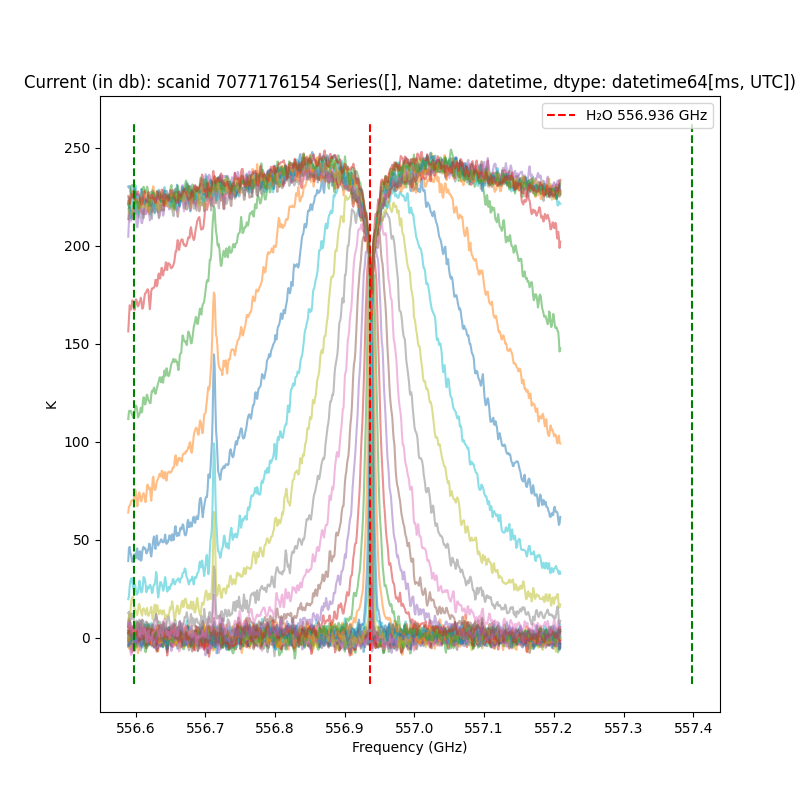

In [13]:
fig,ax = plt.subplots(figsize=(8, 8))
ax.plot(
    (LO_freq[:,None] + if_freq[None,:] ).T/1e9,
    data.T,
    alpha=0.5,)

ax.vlines(
        x=[556.936, 556.598, 557.398],
        ymin=ax.get_ylim()[0],
        ymax=ax.get_ylim()[1],
        colors=["r","g","g"],
        linestyles="--",
        label="H₂O 556.936 GHz",
    )
ax.legend()
ax.set_xlabel("Frequency (GHz)")
ax.set_title(f"Current (in db): scanid {stw1} {l1.attitude.datetime.loc[stw1:stw1-1]}")
ax.set_ylabel("K")
plt.show()

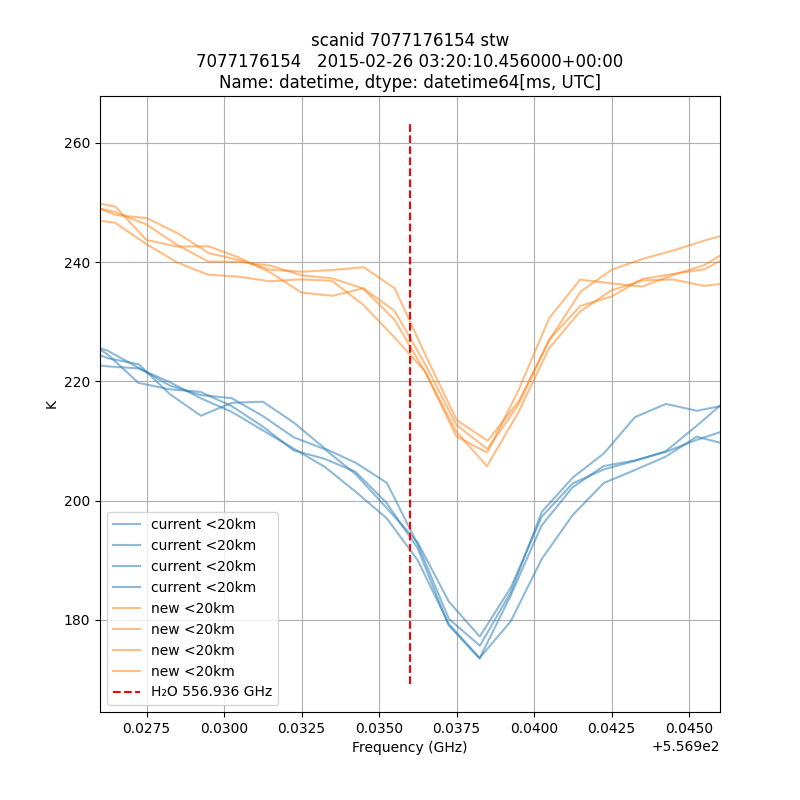

In [14]:
low_mask = (l1.specs.loc[stw1:stw2].t_height < 20).to_numpy()
low_mask_db = alt<20000
fig,ax = plt.subplots(figsize=(8, 8))
ax.plot(
    (LO_freq[low_mask_db][:,None] + if_freq[None,:] ).T/1e9,
    data[low_mask_db].T,
    alpha=0.5,
    label="current <20km",
    color="C0",
    )
ax.plot(
    x[low_mask].T / 1e9,
    # l1.frequency_grid["frequency_grid"].iloc[1].reshape(-1, 112 * 8).T / 1e9,
    y[low_mask].T,
    # ls="none",
    # marker=".",
    alpha=0.5,
    label="new <20km",
    color="C1",
)
ax.vlines(
        x=[556.936, 556.598, 557.398],
        ymin=ax.get_ylim()[0],
        ymax=ax.get_ylim()[1],
        colors=["r","g","g"],
        linestyles="--",
        label="H₂O 556.936 GHz",
    )
ax.legend()
ax.set_xlabel("Frequency (GHz)")
ax.set_title(f"scanid {stw1} {l1.attitude.datetime.loc[stw1-1:stw1+1]}")
ax.set_ylabel("K")
ax.set_xlim(556.936-.01,556.936+.01)
# ax.set_ylim(150,260)
ax.grid(True)
plt.show()

In [15]:
l1.attitude.loc[stw1:stw2,"mjd"]

stw
7077176154    57079.139010
7077176186    57079.139033
7077176218    57079.139056
7077176250    57079.139079
7077176282    57079.139102
                  ...     
7077178841    57079.140953
7077178873    57079.140977
7077178905    57079.141000
7077178937    57079.141023
7077178969    57079.141046
Name: mjd, Length: 89, dtype: float64

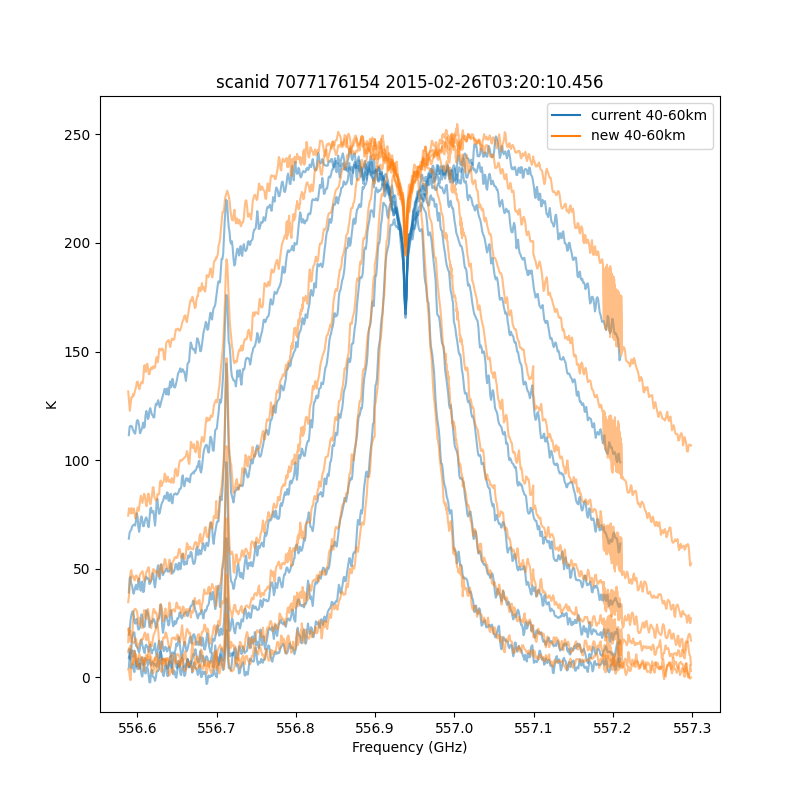

In [24]:
low_mask = (
    (l1.specs.loc[stw1:stw2].t_height > 40) & (l1.specs.loc[stw1:stw2].t_height < 60)
).to_numpy()
low_mask_db = (alt < 60000) & (alt > 40000)
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(
    (LO_freq[low_mask_db][:, None] + if_freq[None, :]).T / 1e9,
    data[low_mask_db].T,
    alpha=0.5,
    color="C0",
)
ax.plot([], [], color="C0", label="current 40-60km")
ax.plot(
    x[low_mask].T / 1e9,
    # l1.frequency_grid["frequency_grid"].iloc[1].reshape(-1, 112 * 8).T / 1e9,
    y[low_mask].T,
    # ls="none",
    # marker=".",
    alpha=0.5,
    color="C1",
)
ax.plot([], [], color="C1", label="new 40-60km")
# ax.vlines(
#     x=[556.936, 556.598, 557.398],
#     ymin=ax.get_ylim()[0],
#     ymax=ax.get_ylim()[1],
#     colors=["r", "g", "g"],
#     linestyles="--",
#     label="H₂O 556.936 GHz",
# )
ax.legend()
ax.set_xlabel("Frequency (GHz)")
ax.set_title(f"scanid {stw1} {l1.attitude.datetime.loc[stw1-1:stw1+1].values[0]}")
ax.set_ylabel("K")
# ax.set_xlim(556.8, 557.1)
# ax.set_ylim(150, 260)
plt.show()

In [17]:
l1.calibrated.loc[stw1:stw2][low_mask]

,calibrated,span,calibrated_T
stw,,,
7077176890,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
7077176954,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
7077177018,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
7077177081,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
7077177145,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
7077177209,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
7077177273,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


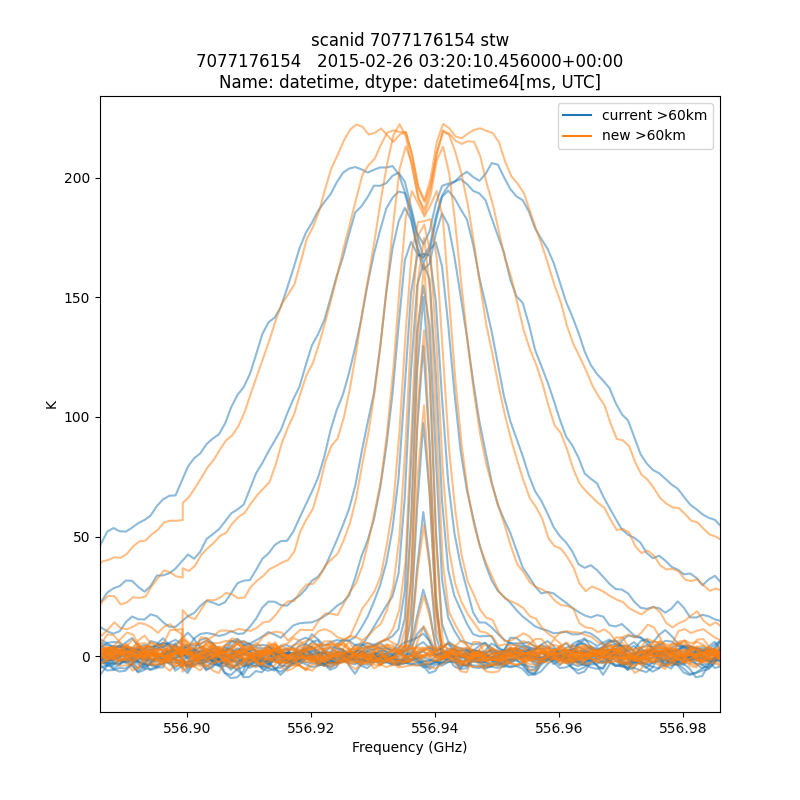

In [18]:
low_mask = (l1.specs.loc[stw1:stw2].t_height > 60).to_numpy()
low_mask_db = alt > 60000
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(
    (LO_freq[low_mask_db][:, None] + if_freq[None, :]).T / 1e9,
    data[low_mask_db].T,
    alpha=0.5,
    color="C0",
    # marker="+",
    # ls="none",
)
ax.plot([], [], color="C0", label="current >60km")
ax.plot(
    x[low_mask].T / 1e9,
    # l1.frequency_grid["frequency_grid"].iloc[1].reshape(-1, 112 * 8).T / 1e9,
    y[low_mask].T,
    # ls="none",
    # marker=".",
    alpha=0.5,
    color="C1",
)
ax.plot([], [], color="C1", label="new >60km")

ax.legend()
ax.set_xlabel("Frequency (GHz)")
ax.set_title(f"scanid {stw1} {l1.attitude.datetime.loc[stw1-1:stw1+1]}")
ax.set_ylabel("K")
ax.set_xlim(556.936-.05,556.936+.05)
# ax.set_ylim(150,260)
plt.show()

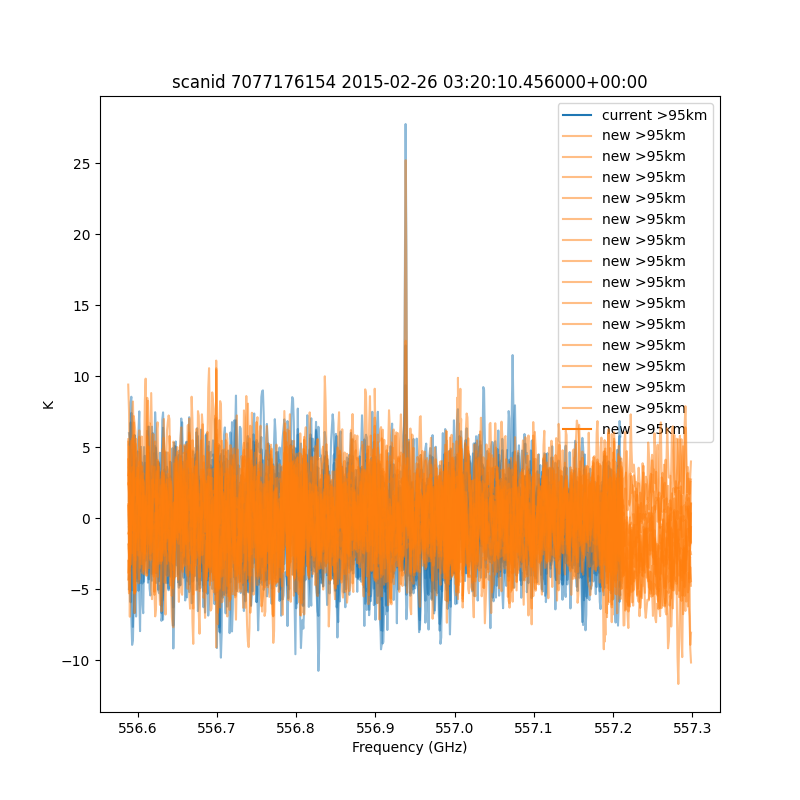

In [19]:
low_mask = (l1.specs.loc[stw1:stw2].t_height > 95).to_numpy()
low_mask_db = alt > 95000
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(
    (LO_freq[low_mask_db][:, None] + if_freq[None, :]).T / 1e9,
    data[low_mask_db].T,
    alpha=0.5,
    color="C0",
    # marker="+",
    # ls="none",
    zorder=15
)
ax.plot([], [], color="C0", label="current >95km")
ax.plot(
    x[low_mask].T / 1e9,
    # l1.frequency_grid["frequency_grid"].iloc[1].reshape(-1, 112 * 8).T / 1e9,
    y[low_mask].T,
    # ls="none",
    # marker=".",
    alpha=0.5,
    color="C1",
    label="new >95km",
    zorder=20
)
ax.plot([], [], color="C1", label="new >95km")

ax.legend()
ax.set_xlabel("Frequency (GHz)")
ax.set_title(f"scanid {stw1} {l1.attitude.datetime.loc[stw1]}")
ax.set_ylabel("K")
# ax.set_xlim(556.8,557.1)
# # ax.set_ylim(150,260)
plt.show()